# Prediction of Accident Severity

This repository holds an attempt to predict the severity of a car accident through machine learning models, using data from "US Accidents (2016 - 2023)" Kaggle data set https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents.

## Overview

The task of this project is to predict the severity of car accidents (levels 1–4) using a large-scale dataset of U.S. traffic accidents. This is formulated as a multiclass classification problem, where the goal is to use features such as weather conditions, time of occurrence, location, and road characteristics to determine how severe an accident will be.

The approach taken in this project involved several stages. First, the dataset was reduced in size and cleaned by removing irrelevant or high-cardinality features, handling missing values, and transforming skewed numerical variables using logarithmic scaling. Categorical features were encoded using one-hot encoding, while care was taken to avoid excessive dimensionality. The dataset was then split into training, validation, and test sets using stratified sampling to preserve the distribution of severity levels. Two machine learning models were implemented and compared: Logistic Regression as a baseline linear model, and Random Forest as a nonlinear model capable of capturing complex relationships. Additionally, class weights were applied to address class imbalance.

In terms of performance, the Random Forest model slightly outperformed Logistic Regression, achieving higher accuracy and better classification metrics overall. The model demonstrated strong predictive ability for the majority classes and improved performance on minority classes after applying class weighting. However, performance on rare severity levels remains a challenge due to the inherent imbalance in the dataset.

## Data Loading and Initial Look

In [1]:
filename="US_Accidents_March23.csv"

In [2]:
!ls -lh

total 2.9G
-rwxrwxrwx 1 maryam maryam 313K Apr 29 11:59 Final_Project-Version1.ipynb
-rwxrwxrwx 1 maryam maryam 2.9G Apr 20 10:38 US_Accidents_March23.csv


In [3]:
!wc -l US_Accidents_March23.csv

7728395 US_Accidents_March23.csv


### Reducing the dataset

In [4]:
!(head -n 1 US_Accidents_March23.csv && tail -n +2 US_Accidents_March23.csv | shuf -n 2000000) > US_Accidents_March23-small.csv

In [5]:
!wc -l US_Accidents_March23-small.csv

2000001 US_Accidents_March23-small.csv


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("US_Accidents_March23-small.csv")

print("Shape:", df.shape)

Shape: (2000000, 46)


### Memory Optimization

In [7]:
# reduce float + int memory usage
# asked ChatGPT for this becuase the kernel kept crashing
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")

for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")

### Intial Look

In [8]:
print(df.head())

          ID   Source  Severity           Start_Time             End_Time  \
0  A-7665703  Source1         2  2017-11-29 14:00:24  2017-11-29 20:00:24   
1  A-4636698  Source1         2  2022-11-01 09:28:00  2022-11-01 11:03:21   
2  A-5709652  Source1         4  2021-05-26 13:05:00  2021-05-26 15:09:39   
3  A-1659905  Source2         2  2020-02-20 07:01:12  2020-02-20 08:15:38   
4  A-1412672  Source2         3  2020-08-05 11:10:46  2020-08-05 15:26:32   

   Start_Lat   Start_Lng    End_Lat     End_Lng  Distance(mi)  ... Roundabout  \
0  33.970909 -117.374992  33.975479 -117.372108         0.356  ...      False   
1  29.452953  -98.497406  29.452944  -98.499306         0.114  ...      False   
2  40.990170  -76.675507  40.998669  -76.747040         3.776  ...      False   
3  33.480598 -111.735840        NaN         NaN         0.000  ...      False   
4  30.302176  -97.714706        NaN         NaN         0.000  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Tu

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int32  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float32
 6   Start_Lng              float32
 7   End_Lat                float32
 8   End_Lng                float32
 9   Distance(mi)           float32
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float32
 21  Wind_Chill(F)          float32
 22  Humidity(%)       

In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 2000000
Columns: 46


### Missing Values

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

End_Lat                  880858
End_Lng                  880858
Precipitation(in)        569865
Wind_Chill(F)            517017
Wind_Speed(mph)          147468
Visibility(mi)            45525
Wind_Direction            45019
Humidity(%)               44769
Weather_Condition         44643
Temperature(F)            42041
Pressure(in)              36198
Weather_Timestamp         30803
Nautical_Twilight          6002
Civil_Twilight             6002
Sunrise_Sunset             6002
Astronomical_Twilight      6002
Airport_Code               5742
Street                     2802
Timezone                   1956
Zipcode                     498
dtype: int64


### Feature Table

In [12]:
summary = []

for col in df.columns:
    feature_type = "Categorical" if df[col].dtype == "object" else "Numerical"
    
    if feature_type == "Numerical":
        value_range = f"{df[col].min()} to {df[col].max()}"
    else:
        value_range = "Multiple categories"
    
    summary.append([
        col,
        feature_type,
        value_range,
        df[col].isnull().sum()
    ])

summary_df = pd.DataFrame(summary, columns=["Feature", "Type", "Range/Values", "Missing Values"])
summary_df.head(46)

,Feature,Type,Range/Values,Missing Values
0,ID,Categorical,Multiple categories,0
1,Source,Categorical,Multiple categories,0
2,Severity,Numerical,1 to 4,0
3,Start_Time,Categorical,Multiple categories,0
4,End_Time,Categorical,Multiple categories,0
5,Start_Lat,Numerical,24.55739974975586 to 49.000579833984375,0
6,Start_Lng,Numerical,-124.5480728149414 to -67.11316680908203,0
7,End_Lat,Numerical,24.569978713989258 to 49.07500076293945,880858
8,End_Lng,Numerical,-124.54574584960938 to -67.10924530029297,880858
9,Distance(mi),Numerical,0.0 to 153.11000061035156,0


### Outliers

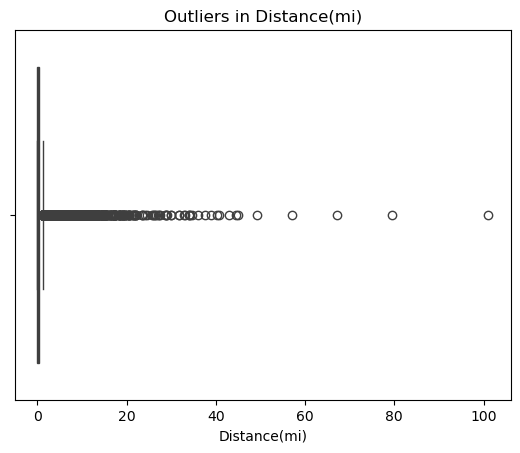

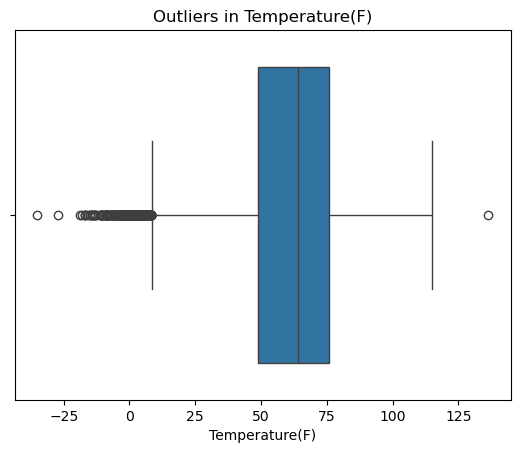

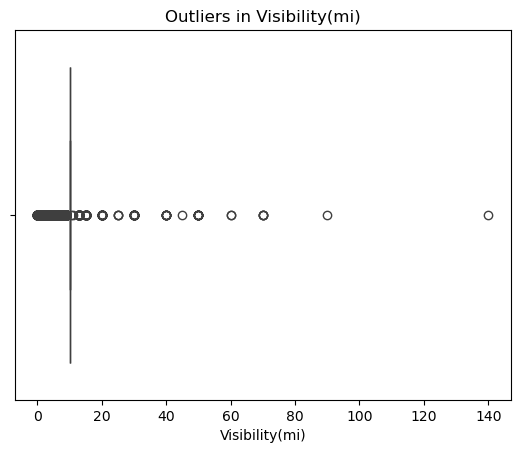

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# visualize a few numerical columns
sample_df = df.sample(50000)

for col in ["Distance(mi)", "Temperature(F)", "Visibility(mi)"]:
    sns.boxplot(x=sample_df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

### Target Class and Class Imbalance

In [14]:
print(df["Severity"].value_counts())
print(df["Severity"].value_counts(normalize=True))

Severity
2    1592552
3     337325
4      52997
1      17126
Name: count, dtype: int64
Severity
2    0.796276
3    0.168662
4    0.026499
1    0.008563
Name: proportion, dtype: float64


## Data Visualization

In [15]:
viz_df = df.sample(50000, random_state=42)

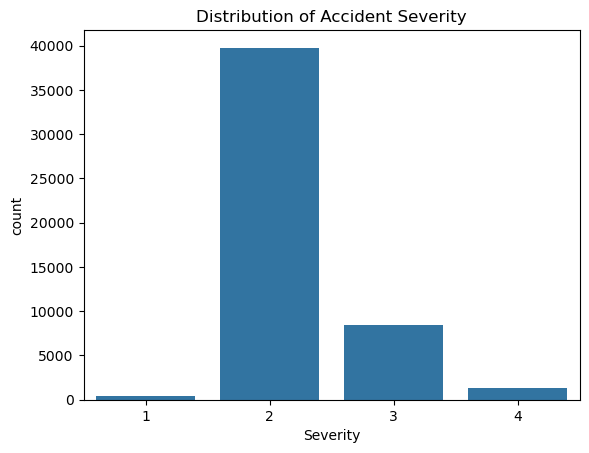

In [16]:
sns.countplot(x="Severity", data=viz_df)
plt.title("Distribution of Accident Severity")
plt.show()

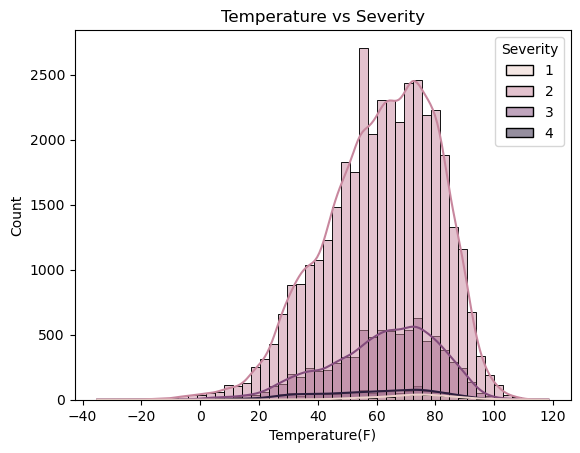

In [17]:
sns.histplot(data=viz_df, x="Temperature(F)", hue="Severity", bins=50, kde=True)
plt.title("Temperature vs Severity")
plt.show()

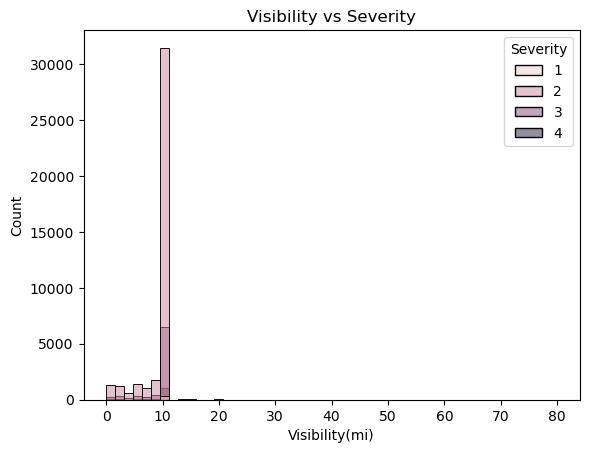

In [18]:
sns.histplot(data=viz_df, x="Visibility(mi)", hue="Severity", bins=50)
plt.title("Visibility vs Severity")
plt.show()

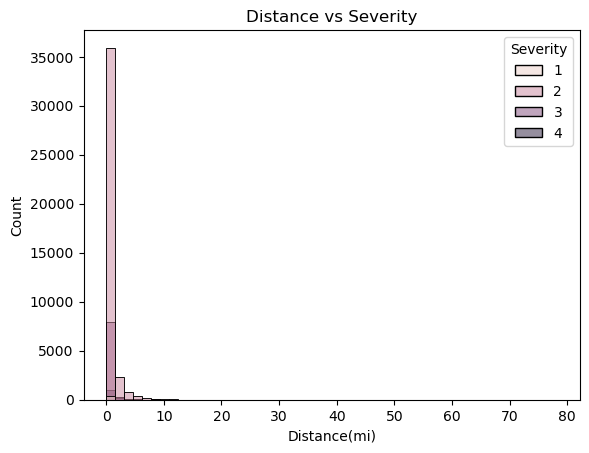

In [19]:
sns.histplot(data=viz_df, x="Distance(mi)", hue="Severity", bins=50)
plt.title("Distance vs Severity")
plt.show()

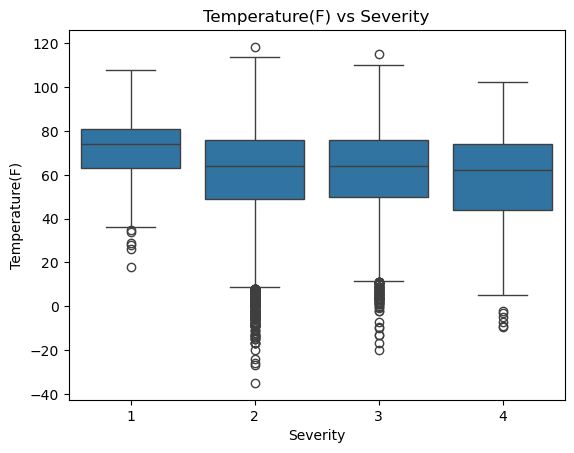

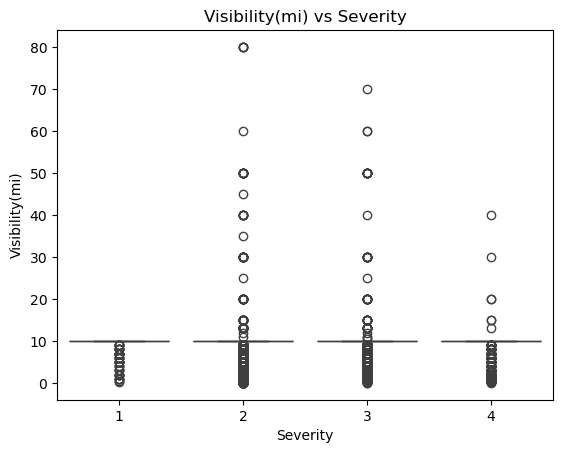

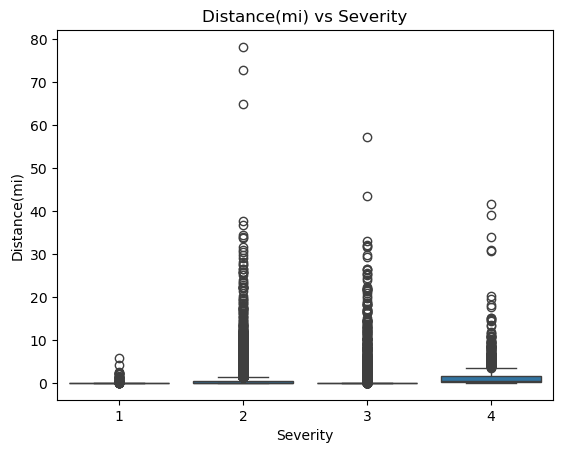

In [20]:
for col in ["Temperature(F)", "Visibility(mi)", "Distance(mi)"]:
    sns.boxplot(x="Severity", y=col, data=viz_df)
    plt.title(f"{col} vs Severity")
    plt.show()

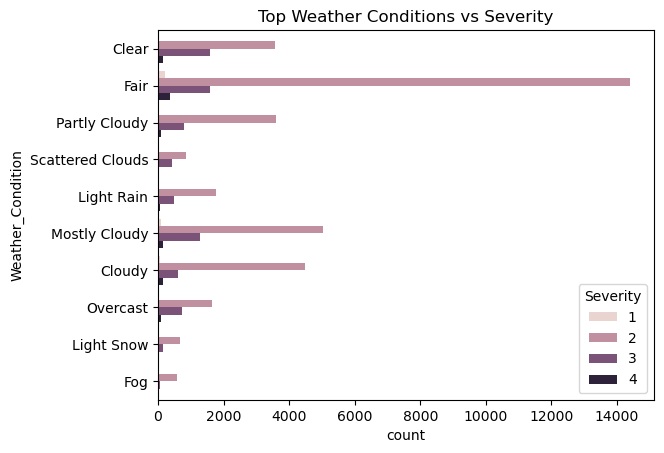

In [23]:
top_weather = viz_df["Weather_Condition"].value_counts().nlargest(10).index

sns.countplot(
    data=viz_df[viz_df["Weather_Condition"].isin(top_weather)],
    y="Weather_Condition",
    hue="Severity")

plt.title("Top Weather Conditions vs Severity")
plt.show()

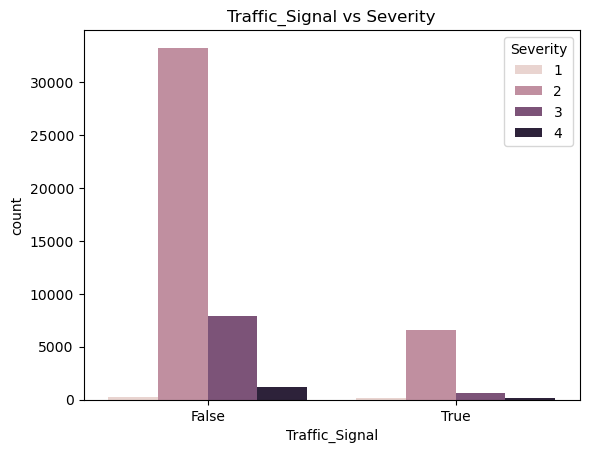

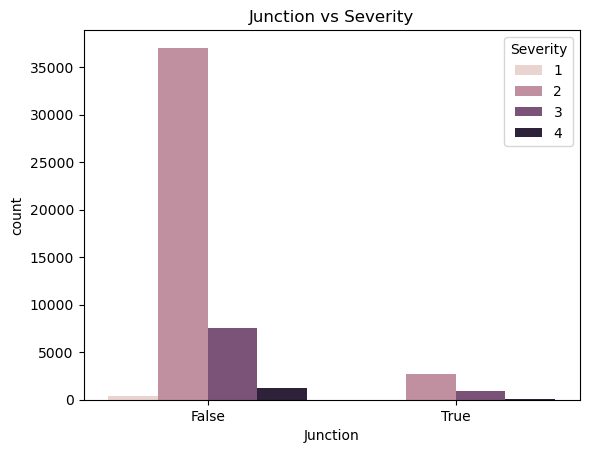

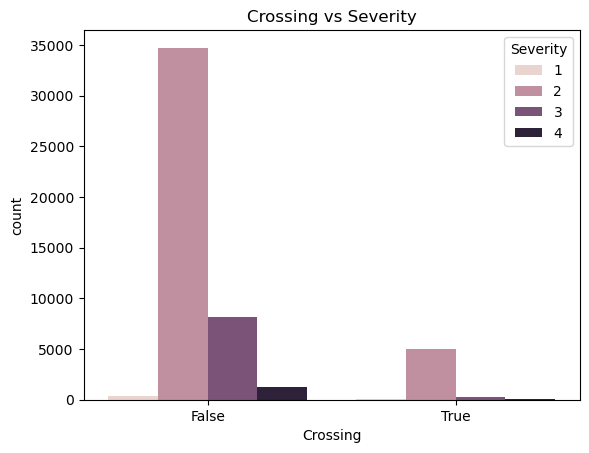

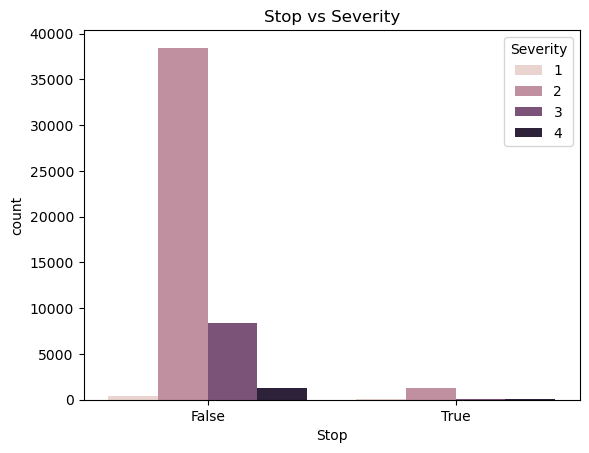

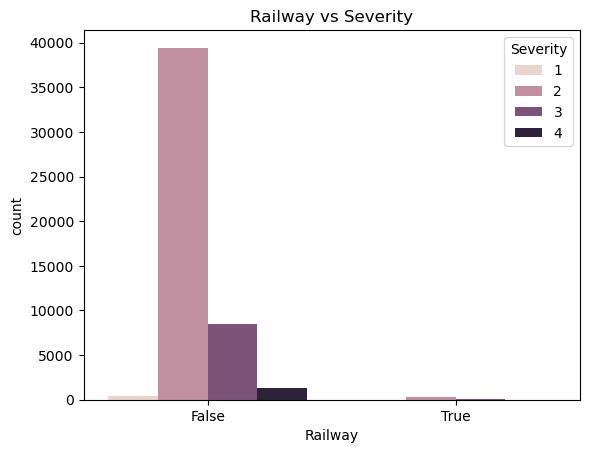

In [24]:
road_features = [
    "Traffic_Signal", "Junction", "Crossing",
    "Stop", "Railway"
]

for col in road_features:
    sns.countplot(x=col, hue="Severity", data=viz_df)
    plt.title(f"{col} vs Severity")
    plt.show()

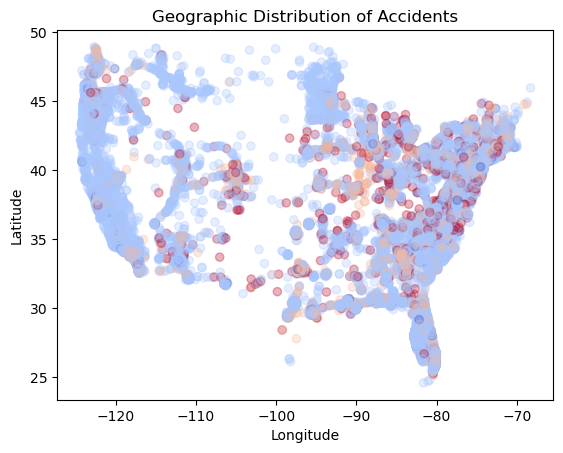

In [25]:
plt.scatter(
    viz_df["Start_Lng"],
    viz_df["Start_Lat"],
    c=viz_df["Severity"],
    cmap="coolwarm",
    alpha=0.3
)

plt.title("Geographic Distribution of Accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

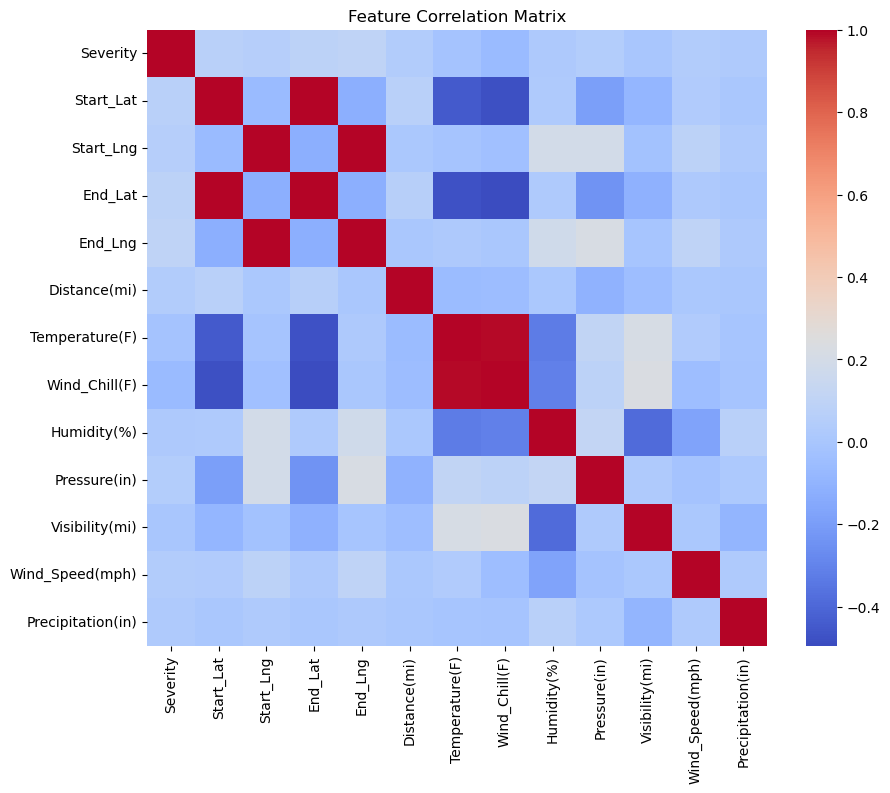

In [26]:
corr = viz_df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## Data Cleaning and Preperation

### Droping Unnecessary Columns

In [27]:
drop_cols = [
    "ID",                # unique identifier (no predictive value)
    "Description",       # large text field (too complex for this model)
    "Street",            # too specific (high cardinality)
    "Zipcode",           # too granular
    "Country",           # constant ('US')
    "Timezone",          # redundant
    "Airport_Code",      # many missing values
    "Weather_Timestamp", # overlaps with Start_Time
    "City",              # too many unique values → would explode encoding
    "County"             # same issue
]

df = df.drop(columns=drop_cols)

### Feature Engineering

In [28]:
# Convert Start_Time to datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

# Extract useful time-based features
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Month"] = df["Start_Time"].dt.month

# Drop original time columns (no longer needed)
df = df.drop(columns=["Start_Time", "End_Time"])

### Handling Missing Values

In [29]:
# numerical → fill with median (robust to outliers)
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical → fill with 'Unknown'
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

### Log Transformation

In [30]:
# apply log transformation safely (handles zeros)
df["Visibility_log"] = np.log1p(df["Visibility(mi)"])
df["Distance_log"] = np.log1p(df["Distance(mi)"])

# drop original skewed columns
df = df.drop(columns=["Visibility(mi)", "Distance(mi)"])

### Convert Boolean Features

In [31]:
# convert True/False → 1/0
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

### One-Hot Encoding

In [32]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(col, df[col].nunique())

Source 3
State 49
Wind_Direction 25
Weather_Condition 126
Sunrise_Sunset 3
Civil_Twilight 3
Nautical_Twilight 3
Astronomical_Twilight 3


In [33]:
# Only encode low-cardinality categorical features because the kernel kept crashing
low_card_cols = [
    "Source",                 # small number of values
    "State",                  # ~50 values → still manageable
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

In [34]:
# keep only top 10 most common weather conditions
top_weather = df["Weather_Condition"].value_counts().nlargest(10).index

df["Weather_Condition"] = df["Weather_Condition"].apply(
    lambda x: x if x in top_weather else "Other"
)

In [35]:
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

## Machine Learning

### Problem Formation 

In [37]:
# Target variable (what we are predicting)
target = "Severity"

# Features (everything else)
X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2000000, 120)
Target shape: (2000000,)


### Training

In [38]:
from sklearn.model_selection import train_test_split

# first split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,          # keeps severity distribution balanced
    random_state=42)

# second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,     # maintain balance again
    random_state=42)

In [39]:
def check_distribution(name, y_data):
    print(f"\n{name} distribution:")
    print(y_data.value_counts(normalize=True))

check_distribution("Train", y_train)
check_distribution("Validation", y_val)
check_distribution("Test", y_test)


Train distribution:
Severity
2    0.796276
3    0.168663
4    0.026499
1    0.008563
Name: proportion, dtype: float64

Validation distribution:
Severity
2    0.796277
3    0.168660
4    0.026500
1    0.008563
Name: proportion, dtype: float64

Test distribution:
Severity
2    0.796277
3    0.168663
4    0.026497
1    0.008563
Name: proportion, dtype: float64


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(
    max_iter=100,
    class_weight="balanced"  )

log_model.fit(X_train_scaled, y_train)

val_pred_log = log_model.predict(X_val_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_val, val_pred_log))
print(classification_report(y_val, val_pred_log))

/usr/lib/python3/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.46320666666666666
              precision    recall  f1-score   support

           1       0.04      0.80      0.08      2569
           2       0.95      0.39      0.56    238883
           3       0.44      0.74      0.55     50598
           4       0.09      0.74      0.15      7950

    accuracy                           0.46    300000
   macro avg       0.38      0.67      0.33    300000
weighted avg       0.83      0.46      0.54    300000



### Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced" )

rf_model.fit(X_train, y_train)

val_pred_rf = rf_model.predict(X_val)

print("Random Forest")
print("Accuracy:", accuracy_score(y_val, val_pred_rf))
print(classification_report(y_val, val_pred_rf))

Random Forest
Accuracy: 0.4723333333333333
              precision    recall  f1-score   support

           1       0.08      0.88      0.14      2569
           2       0.97      0.39      0.56    238883
           3       0.41      0.78      0.54     50598
           4       0.08      0.82      0.15      7950

    accuracy                           0.47    300000
   macro avg       0.39      0.72      0.35    300000
weighted avg       0.85      0.47      0.54    300000



## Performance Comparison

In [44]:
log_acc = accuracy_score(y_val, val_pred_log)
rf_acc = accuracy_score(y_val, val_pred_rf)

print(f"Logistic Regression: {log_acc:.4f}")
print(f"Random Forest:     {rf_acc:.4f}")

Logistic Regression: 0.4632
Random Forest:     0.4723


In [45]:
best_model = rf_model 

test_pred = best_model.predict(X_test)

print("Final Test Performance")
print("Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

Final Test Performance
Accuracy: 0.47078
              precision    recall  f1-score   support

           1       0.08      0.88      0.14      2569
           2       0.97      0.39      0.56    238883
           3       0.41      0.78      0.54     50599
           4       0.08      0.81      0.15      7949

    accuracy                           0.47    300000
   macro avg       0.39      0.71      0.35    300000
weighted avg       0.85      0.47      0.54    300000



### Confusion Matrix

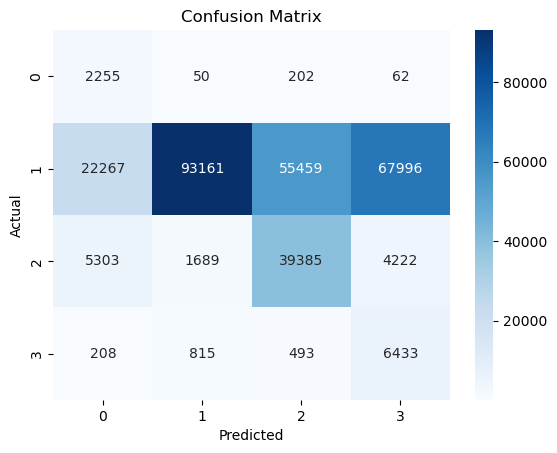

In [47]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, test_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Conclusions

From this project, several important conclusions can be drawn. First, accident severity can not be fully predicted using environmental, temporal, and road-related features, indicating that these factors play a significant role in determining accident outcomes. Among the models tested, Random Forest outperformed Logistic Regression, meaning that nonlinear relationships between variables are important in this problem.

One of the main reasons for this is the impact of class imbalance. The dataset is heavily dominated by mid-level severity accidents, which can bias models toward predicting those classes. Applying class weights improved the model’s ability to detect rare but important severe accidents, although challenges still remain in accurately predicting the least frequent classes.

## Future Work

There are several directions for improving and extending this work. One immediate next step would be to perform hyperparameter tuning on the models, particularly the Random Forest, to further improve performance. Also, experimenting with more advanced models such as Gradient Boosting or ensemble methods could yield better predictive accuracy.

Another important area for future work is addressing class imbalance more effectively. Techniques such as SMOTE or other resampling strategies could be explored to improve performance on rare severity classes.

Further studies could also focus on feature selection and importance analysis to better understand which variables contribute most to accident severity. This could provide valuable real-world insights for traffic safety and policy-making.